In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('paper')

eu = pd.read_csv('/srv/scratch/z3532965/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACPOLR2A_CRC_EU/mACPOLR2A_CRC_EU_4h_normalized.csv')
pser2 = pd.read_csv('/srv/scratch/z3532965/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACPOLR2A_Kinetic_pSer2/mACPOLR2A_pSer2_4h_normalized.csv')

In [3]:
pser2

,DRUG_CONCENTRATION,Mean,SD,N
0,0,1.000000,0.073454,36
1,10,0.951075,0.071325,12
2,100,0.801168,0.064048,12
3,1000,0.696767,0.062452,12
4,10000,0.680074,0.038410,12


In [4]:
eu

,DRUG_CONCENTRATION,TIME_MINUTES,Mean,SD,N
0,0,240,1.000000,0.099601,80
1,3,240,0.964823,0.094329,20
2,10,240,0.944433,0.088845,20
3,30,240,0.863625,0.086110,20
4,100,240,0.762100,0.085700,20
5,300,240,0.705944,0.090980,20
6,1000,240,0.678218,0.096454,20


In [5]:
plot_df = (
    eu[['DRUG_CONCENTRATION', 'Mean', 'SD']]
    .rename(columns={'Mean': 'EU_Mean', 'SD': 'EU_SD'})
    .merge(
        pser2[['DRUG_CONCENTRATION', 'Mean', 'SD']]
        .rename(columns={'Mean': 'pSer2_Mean', 'SD': 'pSer2_SD'}),
        on=['DRUG_CONCENTRATION'],
        how='inner'
    )
    .sort_values('DRUG_CONCENTRATION')
    .reset_index(drop=True)
)

In [6]:
plot_df

,DRUG_CONCENTRATION,EU_Mean,EU_SD,pSer2_Mean,pSer2_SD
0,0,1.000000,0.099601,1.000000,0.073454
1,10,0.944433,0.088845,0.951075,0.071325
2,100,0.762100,0.085700,0.801168,0.064048
3,1000,0.678218,0.096454,0.696767,0.062452


,DRUG_CONCENTRATION,EU_Mean,EU_SD,pSer2_Mean,pSer2_SD,Condition
0,0,1.000000,0.099601,1.000000,0.073454,0
1,10,0.944433,0.088845,0.951075,0.071325,10
2,100,0.762100,0.085700,0.801168,0.064048,100
3,1000,0.678218,0.096454,0.696767,0.062452,1000


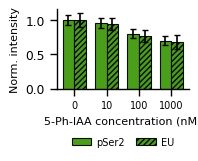

In [22]:
plot_df['Condition'] = plot_df['DRUG_CONCENTRATION'].map(lambda x: f'{x:g}')
condition_order = plot_df['Condition'].tolist()

f, a = plt.subplots(figsize=(2.5, 1.5), layout='constrained')

x = np.arange(len(plot_df))
width = 0.36

# Same fill color, dense hatch on one assay to distinguish the bars
a.bar(
    x - width/2, plot_df['pSer2_Mean'], width=width, yerr=plot_df['pSer2_SD'],
    capsize=2, color='xkcd:grass green', edgecolor='black', linewidth=0.8,
    hatch='', alpha=0.95, label='pSer2'
)
a.bar(
    x + width/2, plot_df['EU_Mean'], width=width, yerr=plot_df['EU_SD'],
    capsize=2, color='xkcd:grass green', edgecolor='black', linewidth=0.8,
    hatch='//////', alpha=0.95, label='EU'
)

a.set_xticks(x)
a.set_xticklabels(condition_order, fontsize=7)
a.set_xlabel('5-Ph-IAA concentration (nM)', fontsize=8)
a.set_ylabel('Norm. intensity', fontsize=8)
a.set_box_aspect(0.6)

a.legend(
    frameon=False,
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.5),
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.5
)
sns.despine(ax=a)

plt.savefig('eu_pser2_grouped_barplot_4h_matched_doses.pdf', bbox_inches='tight')
plt.savefig('eu_pser2_grouped_barplot_4h_matched_doses.svg', bbox_inches='tight')
plot_df